In [ ]:
# ── Install ──────────────────────────────────────────────────────────────────
import sys, subprocess
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install',
    'tensorflow', 'numpy', 'pandas',
    'matplotlib', 'seaborn', 'scikit-learn', 'Pillow',
    '--quiet'
])

# ── Standard library ─────────────────────────────────────────────────────────
import os, random, warnings, itertools
warnings.filterwarnings('ignore')

# ── Numerics & plotting ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

# ── TensorFlow / Keras ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

# ── Reproducibility ───────────────────────────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
print(f'NumPy      : {np.__version__}')
gpu = tf.config.list_physical_devices('GPU')
print(f'GPU        : {gpu if gpu else "None — consider Runtime > Change runtime type > GPU"}')
print('\n✅ All imports successful!')

TensorFlow : 2.20.0
Keras      : 3.13.2
NumPy      : 2.0.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

✅ All imports successful!


In [ ]:
import sys, subprocess
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install',
    'tensorflow', 'numpy', 'pandas',
    'matplotlib', 'seaborn', 'scikit-learn', 'Pillow',
    '--quiet'
])

# ── Standard library ─────────────────────────────────────────────────────────
import os, random, warnings, itertools
warnings.filterwarnings('ignore')

# ── Numerics & plotting ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

# ── TensorFlow / Keras ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ── Reproducibility ───────────────────────────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
print(f'NumPy      : {np.__version__}')
gpu = tf.config.list_physical_devices('GPU')
print(f'GPU        : {gpu if gpu else "None — consider Runtime > Change runtime type > GPU"}')
print('\n✅ All imports successful!')
# ── Option A: Mount Google Drive (if files are stored there) ─────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print('Running in Google Colab')
except ImportError:
    IN_COLAB = False
    print('Running locally')

# ── Option B: Upload files directly in Colab ─────────────────────────────────
# from google.colab import files
# uploaded = files.upload()   # pick combined_80000idx_dataset.csv

# ── CONFIG ────────────────────────────────────────────────────────────────────
# Update these paths to match where your CSV lives:
if IN_COLAB:
    # Example: '/content/drive/MyDrive/combined_80000idx_dataset.csv'
    # OR just '/content/combined_80000idx_dataset.csv' if uploaded directly
    MNIST_CSV  = '/content/mnist_80000idx_sample.csv'
    EMNIST_CSV = '/content/emnist_50000idx_sample.csv'
else:
    MNIST_CSV  = 'mnist_80000idx_sample.csv'
    EMNIST_CSV = 'emnist_50000idx_sample.csv'

# ── CRNN Hyper-parameters ─────────────────────────────────────────────────────
IMG_H          = 32       # fixed image height fed to CRNN
IMG_W          = 128      # fixed image width  fed to CRNN
MAX_WORD_LEN   = 8        # max characters in a synthetic word
MIN_WORD_LEN   = 2        # min characters in a synthetic word
NUM_WORDS      = 20000     # synthetic word images to generate
BATCH_SIZE     = 32
EPOCHS         = 100
LSTM_UNITS     = 256

# ── Character set ─────────────────────────────────────────────────────────────
# EMNIST Balanced: 0-9 → digits, 10-35 → A-Z
CHARS      = [str(d) for d in range(10)] + [chr(c) for c in range(ord('A'), ord('Z')+1)]
NUM_CHARS  = len(CHARS)          # 36
BLANK_IDX  = NUM_CHARS           # 36  (CTC blank token)
NUM_LABELS = NUM_CHARS + 1       # 37  (36 chars + blank)

char2idx = {c: i for i, c in enumerate(CHARS)}
idx2char = {i: c for c, i in char2idx.items()}

print(f'Character set ({NUM_CHARS}): {CHARS}')
print(f'CTC blank index: {BLANK_IDX}')

TensorFlow : 2.20.0
Keras      : 3.13.2
NumPy      : 2.0.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

✅ All imports successful!
Mounted at /content/drive
Running in Google Colab
Character set (36): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
CTC blank index: 36


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow_datasets as tfds

def build_char_bank_from_tfds():
    """
    Load EMNIST Balanced from TFDS and build a dict: label_index -> list of 28x28 uint8 images.
    """
    bank = {i: [] for i in range(NUM_CHARS)}

    print(f'Loading EMNIST Balanced dataset from TensorFlow Datasets...', end=' ')
    ds, ds_info = tfds.load('emnist/balanced', split='train', with_info=True)
    print('Done.')

    total_images = 0
    for example in tfds.as_numpy(ds):
        label = int(example['label'])
        # Only include labels that are within our defined CHARS (0-9, A-Z)
        if label < NUM_CHARS:
            img = example['image'].squeeze() # Remove channel dimension (28, 28, 1) -> (28, 28)
            bank[label].append(img)
            total_images += 1

    print(f'\nCharacter bank ready: {total_images} total images across {NUM_CHARS} classes')
    for i, c in enumerate(CHARS):
        print(f'  [{i:2d}] "{c}" : {len(bank[i])} samples', end='   ')
        if (i + 1) % 6 == 0:
            print()
    print()
    return bank

# Call the function to build the character bank
char_bank = build_char_bank_from_tfds()

Loading EMNIST Balanced dataset from TensorFlow Datasets... 

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/balanced/incomplete.HBRPOI_3.1.0/emnist-train.tfrecord*...:   0%|  …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/balanced/incomplete.HBRPOI_3.1.0/emnist-test.tfrecord*...:   0%|   …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/balanced/3.1.0. Subsequent calls will reuse this data.
Done.

Character bank ready: 86400 total images across 36 classes
  [ 0] "0" : 2400 samples     [ 1] "1" : 2400 samples     [ 2] "2" : 2400 samples     [ 3] "3" : 2400 samples     [ 4] "4" : 2400 samples     [ 5] "5" : 2400 samples   
  [ 6] "6" : 2400 samples     [ 7] "7" : 2400 samples     [ 8] "8" : 2400 samples     [ 9] "9" : 2400 samples     [10] "A" : 2400 samples     [11] "B" : 2400 samples   
  [12] "C" : 2400 samples     [13] "D" : 2400 samples     [14] "E" : 2400 samples     [15] "F" : 2400 samples     [16] "G" : 2400 samples     [17] "H" : 2400 samples   
  [18] "I" : 2400 samples     [19] "J" : 2400 samples     [20] "K" : 2400 samples     [21] "L" : 2400 samples     [22] "M" : 2400 samples     [23] "N" : 2400 samples   
  [24] "O" : 2400 samples     [25] "P" : 2400 samples     [26] "Q" : 2400 samples     [27] "R" : 2400 samples     [28] "S" : 240

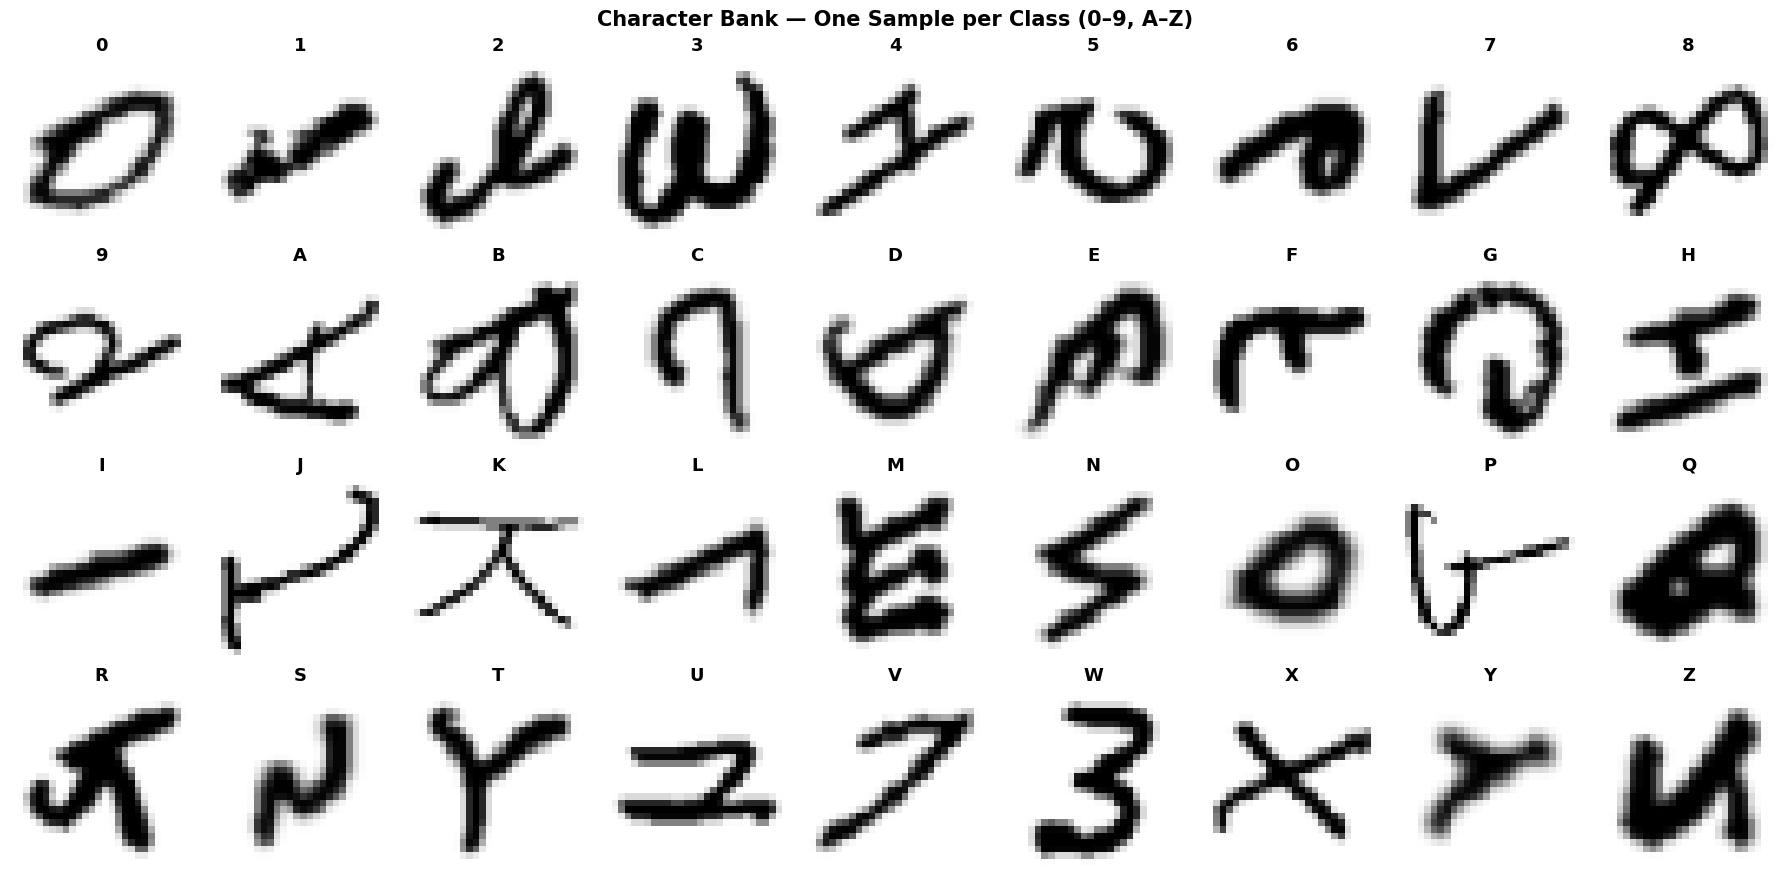

In [ ]:
fig, axes = plt.subplots(4, 9, figsize=(18, 9))
axes = axes.flatten()

for idx in range(NUM_CHARS):
    if char_bank[idx]:
        img = char_bank[idx][0]
        axes[idx].imshow(img, cmap='gray_r')
        axes[idx].set_title(f'{CHARS[idx]}', fontsize=13, fontweight='bold')
    axes[idx].axis('off')

# hide unused axes
for idx in range(NUM_CHARS, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Character Bank — One Sample per Class (0–9, A–Z)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Word "HELLO" → image shape: (32, 128)


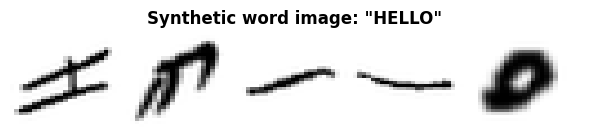

In [ ]:
def make_word_image(word_str, char_bank, img_h=IMG_H, img_w=IMG_W, augment=True):
    """
    Build a (img_h, img_w) grayscale image for a given word string.
    Characters are stitched horizontally with small random gaps.
    """
    tiles = []
    for ch in word_str:
        idx = char2idx.get(ch)
        if idx is None or not char_bank[idx]:
            continue
        tile = random.choice(char_bank[idx]).copy().astype(np.float32)

        if augment:
            # random brightness / contrast jitter
            tile = tile * np.random.uniform(0.8, 1.2)
            tile = np.clip(tile, 0, 255)
            # random thin vertical gap
            gap = np.zeros((28, random.randint(1, 4)), dtype=np.float32)
            tiles.append(tile)
            tiles.append(gap)
        else:
            gap = np.zeros((28, 2), dtype=np.float32)
            tiles.append(tile)
            tiles.append(gap)

    if not tiles:
        return np.zeros((img_h, img_w), dtype=np.float32)

    strip = np.hstack(tiles)          # (28, total_width)

    # Resize to fixed (img_h, img_w) using PIL
    pil_img = Image.fromarray(strip.astype(np.uint8)).resize(
        (img_w, img_h), Image.LANCZOS
    )
    final = np.array(pil_img, dtype=np.float32) / 255.0
    return final


def random_word(min_len=MIN_WORD_LEN, max_len=MAX_WORD_LEN):
    """Generate a random alphanumeric word using available characters."""
    length = random.randint(min_len, max_len)
    return ''.join(random.choices(CHARS, k=length))


# Quick smoke test
test_word  = 'HELLO'
test_image = make_word_image(test_word, char_bank, augment=False)
print(f'Word "{test_word}" → image shape: {test_image.shape}')

plt.figure(figsize=(6, 1.5))
plt.imshow(test_image, cmap='gray_r', aspect='auto')
plt.title(f'Synthetic word image: "{test_word}"', fontsize=12, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

Generating 20000 synthetic word images ...
  Generated 500/20000 word images...
  Generated 1000/20000 word images...
  Generated 1500/20000 word images...
  Generated 2000/20000 word images...
  Generated 2500/20000 word images...
  Generated 3000/20000 word images...
  Generated 3500/20000 word images...
  Generated 4000/20000 word images...
  Generated 4500/20000 word images...
  Generated 5000/20000 word images...
  Generated 5500/20000 word images...
  Generated 6000/20000 word images...
  Generated 6500/20000 word images...
  Generated 7000/20000 word images...
  Generated 7500/20000 word images...
  Generated 8000/20000 word images...
  Generated 8500/20000 word images...
  Generated 9000/20000 word images...
  Generated 9500/20000 word images...
  Generated 10000/20000 word images...
  Generated 10500/20000 word images...
  Generated 11000/20000 word images...
  Generated 11500/20000 word images...
  Generated 12000/20000 word images...
  Generated 12500/20000 word images...
  

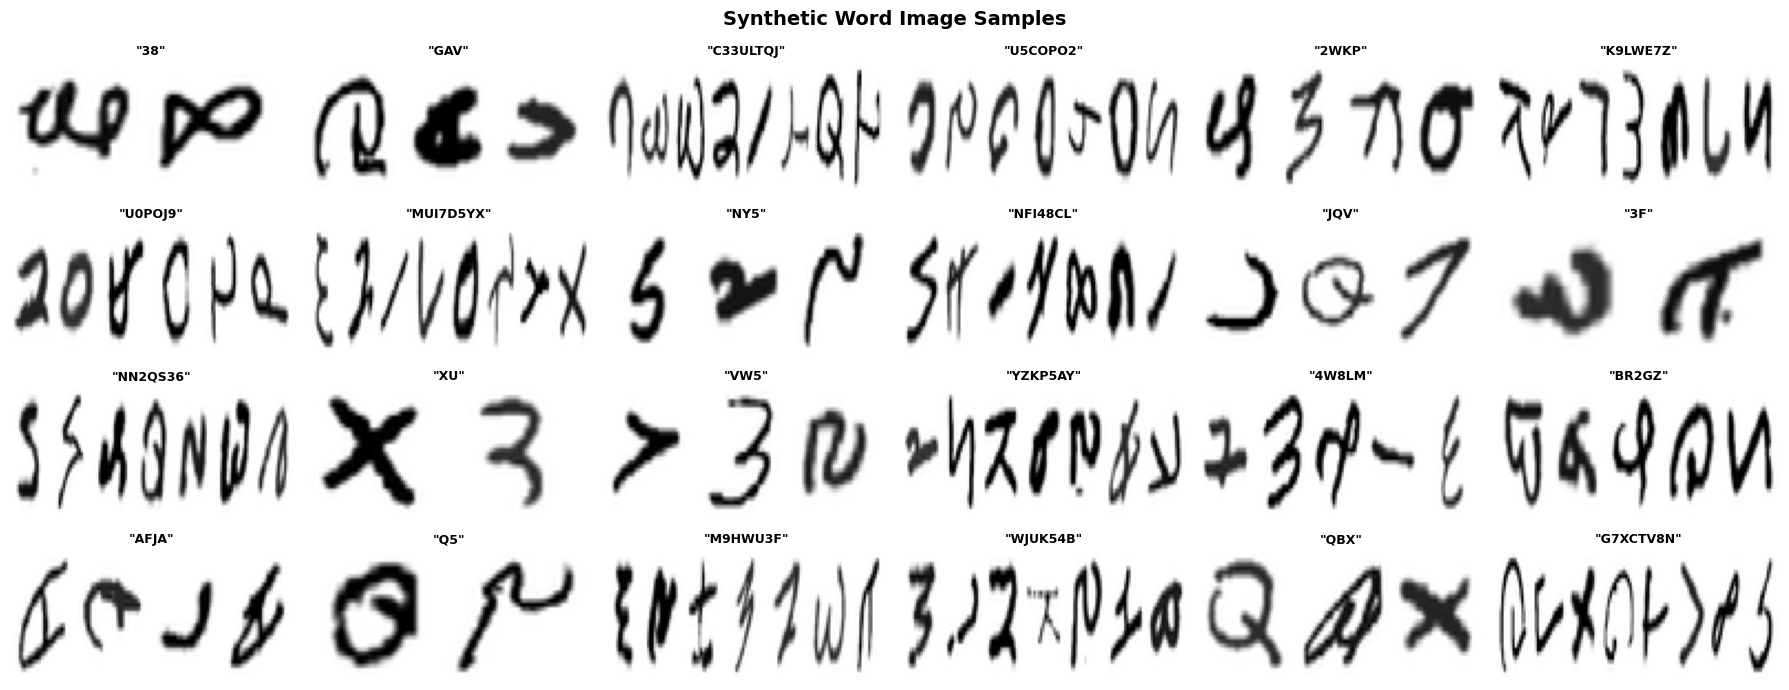

In [ ]:
def build_dataset(n_words, char_bank):
    """
    Generate n_words (image, label_str) pairs.
    Returns:
      images      : np.ndarray  (N, IMG_H, IMG_W, 1)  float32
      label_strs  : list of str
    """
    images     = []
    label_strs = []

    for i in range(n_words):
        word  = random_word()
        img   = make_word_image(word, char_bank, augment=True)
        images.append(img[..., np.newaxis])   # add channel dim
        label_strs.append(word)

        if (i + 1) % 500 == 0:
            print(f'  Generated {i+1}/{n_words} word images...')

    return np.array(images, dtype=np.float32), label_strs


print(f'Generating {NUM_WORDS} synthetic word images ...')
X_all, y_all_str = build_dataset(NUM_WORDS, char_bank)

print(f'\nDataset ready:')
print(f'  Images shape : {X_all.shape}  (N, H, W, C)')
print(f'  Label samples: {y_all_str[:10]}')

# Show a grid of generated word images
fig, axes = plt.subplots(4, 6, figsize=(18, 7))
axes = axes.flatten()
for i in range(24):
    axes[i].imshow(X_all[i, :, :, 0], cmap='gray_r', aspect='auto')
    axes[i].set_title(f'"{y_all_str[i]}"', fontsize=9, fontweight='bold')
    axes[i].axis('off')
plt.suptitle('Synthetic Word Image Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
def encode_labels(label_strs, max_len=MAX_WORD_LEN):
    """
    Convert list of strings to padded integer sequences.
    Returns:
      encoded      : (N, max_len)  int32  — padded with -1
      label_lengths: (N, 1)        int32  — true length of each label
    """
    encoded       = np.full((len(label_strs), max_len), -1, dtype=np.int32)
    label_lengths = np.zeros((len(label_strs), 1), dtype=np.int32)

    for i, word in enumerate(label_strs):
        seq = [char2idx[c] for c in word if c in char2idx]
        seq = seq[:max_len]
        encoded[i, :len(seq)] = seq
        label_lengths[i, 0]   = len(seq)

    return encoded, label_lengths


labels_encoded, label_lengths = encode_labels(y_all_str)

print('Label encoding shapes:')
print(f'  encoded       : {labels_encoded.shape}')
print(f'  label_lengths : {label_lengths.shape}')
print(f'\nExample  word="{y_all_str[0]}"  → encoded={labels_encoded[0]}  len={label_lengths[0,0]}')

Label encoding shapes:
  encoded       : (20000, 8)
  label_lengths : (20000, 1)

Example  word="38"  → encoded=[ 3  8 -1 -1 -1 -1 -1 -1]  len=2


## ✂️ Cell 8 — Train / Validation / Test Split

In [ ]:
indices = np.arange(len(X_all))

# 70 / 15 / 15
idx_train, idx_temp = train_test_split(indices, test_size=0.30, random_state=42)
idx_val,   idx_test = train_test_split(idx_temp, test_size=0.50, random_state=42)

X_train = X_all[idx_train];  y_train = labels_encoded[idx_train]; yl_train = label_lengths[idx_train]
X_val   = X_all[idx_val];    y_val   = labels_encoded[idx_val];   yl_val   = label_lengths[idx_val]
X_test  = X_all[idx_test];   y_test  = labels_encoded[idx_test];  yl_test  = label_lengths[idx_test]
ws_train = [y_all_str[i] for i in idx_train]
ws_test  = [y_all_str[i] for i in idx_test]

print(f'Train      : {X_train.shape[0]} samples')
print(f'Validation : {X_val.shape[0]} samples')
print(f'Test       : {X_test.shape[0]} samples')

Train      : 14000 samples
Validation : 3000 samples
Test       : 3000 samples


In [ ]:
def build_crnn(img_h=IMG_H, img_w=IMG_W, num_labels=NUM_LABELS, lstm_units=LSTM_UNITS):
    """
    Pure prediction model (no CTC loss built-in).
    Returns (model, input_lengths_val) where input_lengths_val is the
    number of time-steps produced by the CNN for one image.
    """
    inp = keras.Input(shape=(img_h, img_w, 1), name='image')

    # ── CNN Backbone ─────────────────────────────────────────────────────────
    def conv_bn_relu(x, filters, kernel=(3,3), padding='same'):
        x = layers.Conv2D(filters, kernel, padding=padding, use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        return x

    x = conv_bn_relu(inp, 64)
    x = layers.MaxPooling2D((2, 2))(x)          # 16 × 64

    x = conv_bn_relu(x, 128)
    x = layers.MaxPooling2D((2, 2))(x)          # 8 × 32

    x = conv_bn_relu(x, 256)
    x = conv_bn_relu(x, 256)
    x = layers.MaxPooling2D((2, 1))(x)          # 4 × 32

    x = conv_bn_relu(x, 512)
    x = conv_bn_relu(x, 512)
    x = layers.MaxPooling2D((2, 1))(x)          # 2 × 32

    x = conv_bn_relu(x, 512, kernel=(2, 2), padding='same')
    x = layers.MaxPooling2D((2, 1))(x)          # 1 × 32

    # ── Collapse height → sequence ────────────────────────────────────────────
    # shape: (batch, 1, time_steps, 512) → (batch, time_steps, 512)
    x = layers.Reshape((-1, 512))(x)            # (batch, time_steps, 512)

    # ── Bidirectional LSTM ────────────────────────────────────────────────────
    x = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=True, dropout=0.25)
    )(x)
    x = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=True, dropout=0.25)
    )(x)

    # ── Output: per-timestep class probabilities ───────────────────────────────
    output = layers.Dense(num_labels, activation='softmax', name='output')(x)

    crnn = models.Model(inputs=inp, outputs=output, name='CRNN')

    # Compute time-steps (width after CNN): feed a dummy image
    dummy       = np.zeros((1, img_h, img_w, 1), dtype=np.float32)
    dummy_out   = crnn(dummy, training=False)
    time_steps  = dummy_out.shape[1]

    return crnn, time_steps


crnn_model, TIME_STEPS = build_crnn()
crnn_model.summary()
print(f'\nCNN output time-steps : {TIME_STEPS}')
print(f'Max label length      : {MAX_WORD_LEN}')
assert TIME_STEPS >= MAX_WORD_LEN, (
    f'TIME_STEPS ({TIME_STEPS}) must be >= MAX_WORD_LEN ({MAX_WORD_LEN}). '
    'Increase IMG_W or reduce MAX_WORD_LEN.'
)

Model: "CRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 32, 128, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 128, 64)    │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 128, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 64, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 32, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 32, 256)     │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 32, 256)     │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 32, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 32, 256)     │       589,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 32, 256)     │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 8, 32, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 32, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 32, 512)     │     1,179,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 32, 512)     │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 4, 32, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 32, 512)     │     2,359,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 32, 512)     │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 4, 32, 512)     │             

 Total params: 8,724,325 (33.28 MB)

 Trainable params: 8,719,845 (33.26 MB)

 Non-trainable params: 4,480 (17.50 KB)


CNN output time-steps : 32
Max label length      : 8


In [ ]:
class CTCLayer(layers.Layer):
    """
    Custom Keras layer that computes CTC loss and adds it to the model.
    During inference this layer is bypassed — we use crnn_model directly.
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.loss_fn = keras.backend.ctc_batch_cost

    def call(self, inputs):
        y_true, y_pred, input_length, label_length = inputs
        loss = self.loss_fn(y_true, y_pred, input_length, label_length)
        self.add_loss(tf.reduce_mean(loss))
        return y_pred   # pass-through for inspection


def build_training_model(crnn, time_steps, max_label_len):
    """
    Wraps the CRNN with CTC loss computation into a trainable Keras model.
    Inputs : image, labels, input_lengths, label_lengths
    Output : y_pred (the CTC loss is added via add_loss)
    """
    img_input       = crnn.input
    y_pred          = crnn.output

    labels          = keras.Input(shape=(max_label_len,), name='labels',       dtype='int32')
    input_lengths   = keras.Input(shape=(1,),             name='input_lengths', dtype='int32')
    label_lengths   = keras.Input(shape=(1,),             name='label_lengths', dtype='int32')

    ctc_out = CTCLayer(name='ctc_loss')(
        [labels, y_pred, input_lengths, label_lengths]
    )

    training_model = models.Model(
        inputs  = [img_input, labels, input_lengths, label_lengths],
        outputs = ctc_out,
        name    = 'CRNN_CTC_Training'
    )
    return training_model


training_model = build_training_model(crnn_model, TIME_STEPS, MAX_WORD_LEN)
training_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3)
    # loss is handled internally by CTCLayer.add_loss
)
print('✅ Training model compiled')

# Build the input_lengths array (same time_steps for every sample)
input_lengths_train = np.full((len(X_train), 1), TIME_STEPS, dtype=np.int32)
input_lengths_val   = np.full((len(X_val),   1), TIME_STEPS, dtype=np.int32)
input_lengths_test  = np.full((len(X_test),  1), TIME_STEPS, dtype=np.int32)

print(f'Training inputs:')
print(f'  images        : {X_train.shape}')
print(f'  labels        : {y_train.shape}')
print(f'  input_lengths : {input_lengths_train.shape}  (all = {TIME_STEPS})')
print(f'  label_lengths : {yl_train.shape}')

✅ Training model compiled
Training inputs:
  images        : (14000, 32, 128, 1)
  labels        : (14000, 8)
  input_lengths : (14000, 1)  (all = 32)
  label_lengths : (14000, 1)


In [ ]:
def ctc_greedy_decode(y_pred, idx2char, blank_idx=BLANK_IDX):
    """
    Best-path (greedy) CTC decode.
    y_pred : (batch, time_steps, num_labels)  float32
    Returns list of decoded strings.
    """
    decoded_strs = []
    for pred in y_pred:
        # argmax at every time step
        indices = np.argmax(pred, axis=-1)          # (time_steps,)
        # collapse repeated chars and remove blanks
        chars   = []
        prev    = None
        for idx in indices:
            if idx != prev:
                if idx != blank_idx:
                    chars.append(idx2char.get(idx, ''))
                prev = idx
        decoded_strs.append(''.join(chars))
    return decoded_strs


def character_accuracy(true_strs, pred_strs):
    """Character-level accuracy (ignores length mismatch by comparing char-by-char)."""
    total_chars, correct_chars = 0, 0
    for t, p in zip(true_strs, pred_strs):
        total_chars   += len(t)
        correct_chars += sum(tc == pc for tc, pc in zip(t, p))
    return correct_chars / max(total_chars, 1)


def word_accuracy(true_strs, pred_strs):
    """Exact word match accuracy."""
    return sum(t == p for t, p in zip(true_strs, pred_strs)) / max(len(true_strs), 1)


# Quick sanity check on untrained model (should be random)
sample_pred    = crnn_model.predict(X_val[:8], verbose=0)
sample_decoded = ctc_greedy_decode(sample_pred, idx2char)
sample_true    = [ws_train[i] for i in range(8)]   # placeholder
print('Untrained model decode samples (random — expected):')
for t, p in zip([y_all_str[i] for i in idx_val[:8]], sample_decoded):
    print(f'  true: {t:10s}  →  decoded: {p}')

Untrained model decode samples (random — expected):
  true: NBOL        →  decoded: LX
  true: RPCW        →  decoded: LX
  true: ZDMOK14A    →  decoded: SX
  true: VH3I7770    →  decoded: SX
  true: 2OX1Q       →  decoded: LX
  true: SLC0LZUF    →  decoded: SX
  true: WF4S53P     →  decoded: SX
  true: XQ323       →  decoded: SX


In [ ]:
class WordAccuracyCallback(keras.callbacks.Callback):
    """Logs word accuracy and character accuracy at end of each epoch."""

    def __init__(self, X_val, y_val_strs, idx2char, crnn_inference_model, batch_size=64):
        super().__init__()
        self.X_val       = X_val
        self.y_val_strs  = y_val_strs
        self.idx2char    = idx2char
        self.crnn_inference_model = crnn_inference_model # Store the inference model
        self.batch_size  = batch_size
        self.word_accs   = []
        self.char_accs   = []

    def on_epoch_end(self, epoch, logs=None):
        preds   = self.crnn_inference_model.predict( # Use the stored crnn_inference_model
            self.X_val, batch_size=self.batch_size, verbose=0
        )
        decoded = ctc_greedy_decode(preds, self.idx2char)
        wa      = word_accuracy(self.y_val_strs, decoded)
        ca      = character_accuracy(self.y_val_strs, decoded)
        self.word_accs.append(wa)
        self.char_accs.append(ca)
        if logs is not None:
            logs['val_word_acc'] = wa
            logs['val_char_acc'] = ca
        print(f'  → val_word_acc: {wa:.3f}  val_char_acc: {ca:.3f}')


val_strs = [y_all_str[i] for i in idx_val]

# Pass the crnn_model to the callback constructor
word_acc_cb = WordAccuracyCallback(X_val, val_strs, idx2char, crnn_model)

callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=12,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=6, min_lr=1e-7, verbose=1
    ),
    ModelCheckpoint(
        'best_crnn.keras', monitor='val_loss',
        save_best_only=True, verbose=0
    ),
    word_acc_cb
]

history = training_model.fit(
    x = {
        'image'        : X_train,
        'labels'       : y_train,
        'input_lengths': input_lengths_train,
        'label_lengths': yl_train
    },
    y = np.zeros(len(X_train)),   # dummy target — loss is from CTCLayer
    batch_size       = BATCH_SIZE,
    epochs           = EPOCHS,
    validation_data  = (
        {
            'image'        : X_val,
            'labels'       : y_val,
            'input_lengths': input_lengths_val,
            'label_lengths': yl_val
        },
        np.zeros(len(X_val))
    ),
    callbacks = callbacks,
    verbose   = 1
)

Epoch 1/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 18.0063  → val_word_acc: 0.188  val_char_acc: 0.674
438/438 ━━━━━━━━━━━━━━━━━━━━ 58s 110ms/step - loss: 11.2751 - val_loss: 5.0920 - learning_rate: 0.0010 - val_word_acc: 0.1877 - val_char_acc: 0.6736
Epoch 2/100
437/438 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 2.4943  → val_word_acc: 0.417  val_char_acc: 0.830
438/438 ━━━━━━━━━━━━━━━━━━━━ 43s 97ms/step - loss: 2.2616 - val_loss: 2.4234 - learning_rate: 0.0010 - val_word_acc: 0.4170 - val_char_acc: 0.8297
Epoch 3/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 1.8310  → val_word_acc: 0.496  val_char_acc: 0.859
438/438 ━━━━━━━━━━━━━━━━━━━━ 45s 102ms/step - loss: 1.7417 - val_loss: 1.9369 - learning_rate: 0.0010 - val_word_acc: 0.4963 - val_char_acc: 0.8591
Epoch 4/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 1.5374  → val_word_acc: 0.490  val_char_acc: 0.857
438/438 ━━━━━━━━━━━━━━━━━━━━ 43s 97ms/step - loss: 1.5059 - val_loss: 1.9538 - learning_rate: 0.0010 - 

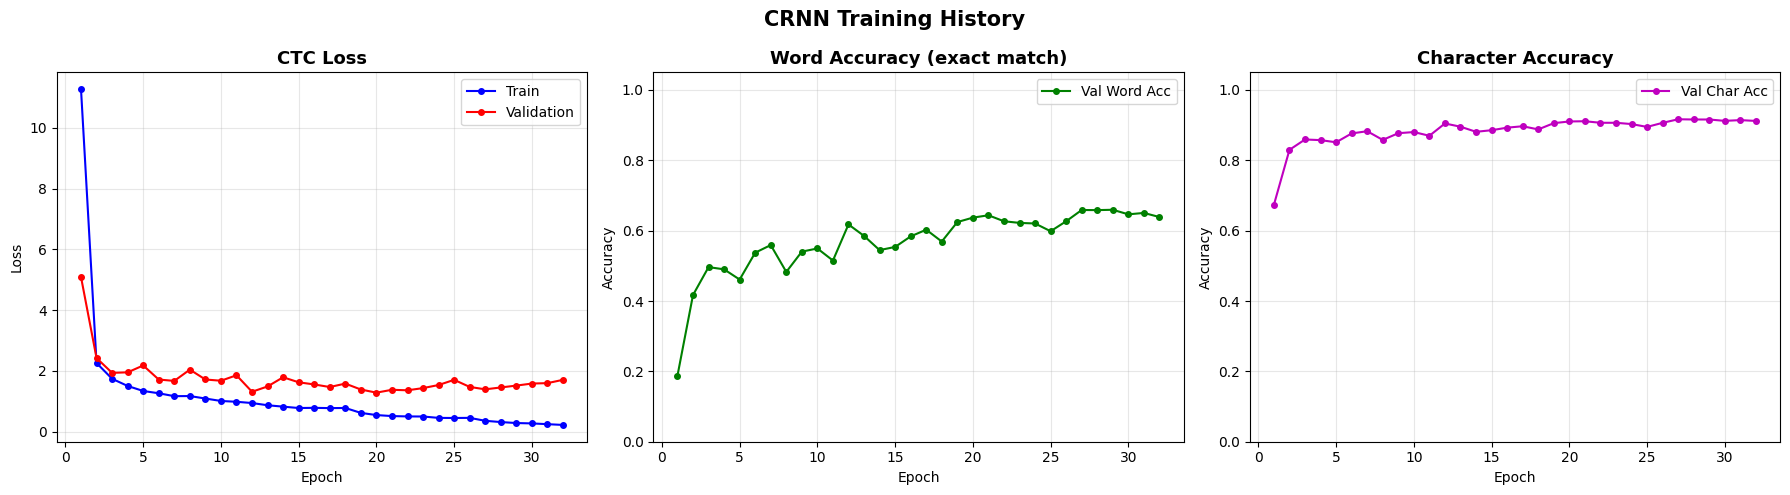

Saved: crnn_training_curves.png


In [ ]:
ep = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CTC Loss
axes[0].plot(ep, history.history['loss'],     'b-o', ms=4, label='Train')
axes[0].plot(ep, history.history['val_loss'], 'r-o', ms=4, label='Validation')
axes[0].set_title('CTC Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Word Accuracy
axes[1].plot(ep, word_acc_cb.word_accs, 'g-o', ms=4, label='Val Word Acc')
axes[1].set_title('Word Accuracy (exact match)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1.05]); axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Char Accuracy
axes[2].plot(ep, word_acc_cb.char_accs, 'm-o', ms=4, label='Val Char Acc')
axes[2].set_title('Character Accuracy', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy')
axes[2].set_ylim([0, 1.05]); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('CRNN Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('crnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: crnn_training_curves.png')

In [ ]:
# Predict on test set using the pure CRNN (no CTC wrapper)
y_pred_raw   = crnn_model.predict(X_test, batch_size=64, verbose=1)
y_pred_strs  = ctc_greedy_decode(y_pred_raw, idx2char)
y_test_strs  = [y_all_str[i] for i in idx_test]

wa = word_accuracy(y_test_strs, y_pred_strs)
ca = character_accuracy(y_test_strs, y_pred_strs)

print(f'\n{"="*46}')
print(f'  Test Word Accuracy      : {wa*100:6.2f}%')
print(f'  Test Character Accuracy : {ca*100:6.2f}%')
print(f'{"="*46}')

# Sample predictions table
print('\nSample Predictions (first 30):')
print(f'{"True":^12}  {"Predicted":^12}  {"Match":^6}')
print('-' * 36)
for t, p in zip(y_test_strs[:30], y_pred_strs[:30]):
    match = '✅' if t == p else '❌'
    print(f'{t:^12}  {p:^12}  {match}')

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step

  Test Word Accuracy      :  65.97%
  Test Character Accuracy :  91.57%

Sample Predictions (first 30):
    True       Predicted    Match 
------------------------------------
    9J6           9J6       ✅
   QIR5V         Q1R5V      ❌
  9G2RZN8U      9G2RZN8U    ✅
     2X            2X       ✅
    C4R           C4R       ✅
  W3QWIDK       W3QW1DK     ❌
    93B9          93B9      ✅
    QCK6          QCK6      ✅
  3L8VOW4       3L8V0W4     ❌
    6ABR          6ABR      ✅
  FHE0K2U0      FHE0KZ40    ❌
  1KI0QMGE      1KI0QMGE    ✅
  71O4UNV       710YUNV     ❌
    Q3PM          Q3P7      ❌
    94RV          94RV      ✅
  LAEB45Y       IAEB45Y     ❌
    BSF           BSF       ✅
    TMZ4          TMX4      ❌
     WM            WM       ✅
    SDG           SDG       ✅
  XWUJYPOD      XWUJ8PDD    ❌
   S3WA1         S3WA1      ✅
    CIOJ          CIOJ      ✅
     IS            1S       ❌
     H7            H7       ✅
  7YLNFI0       7YLNF10     ❌
  M

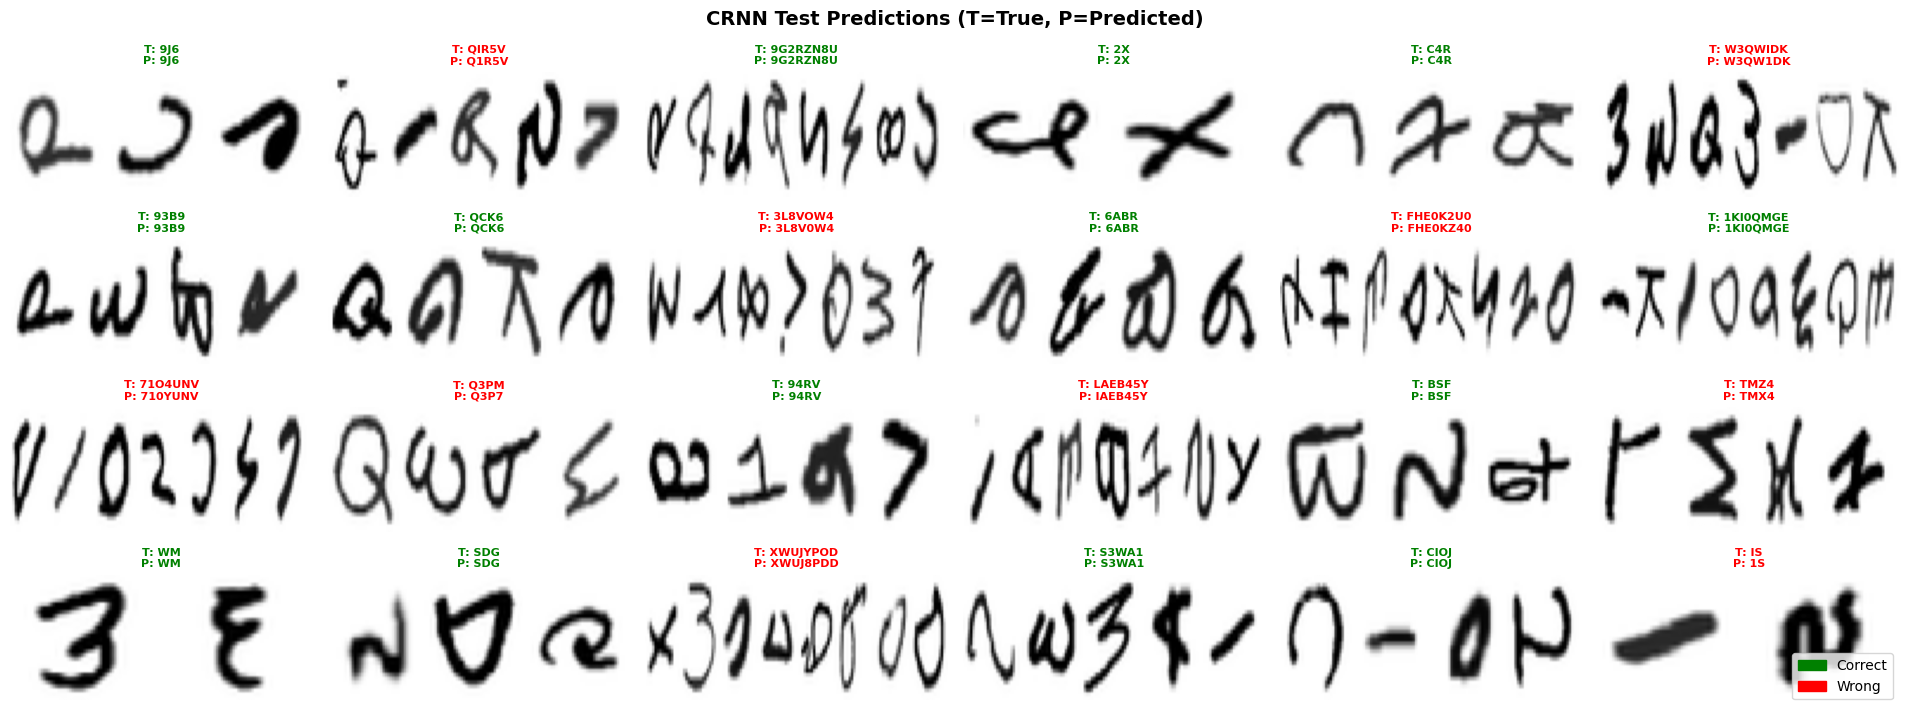

Correct predictions: 1979
Wrong   predictions: 1021


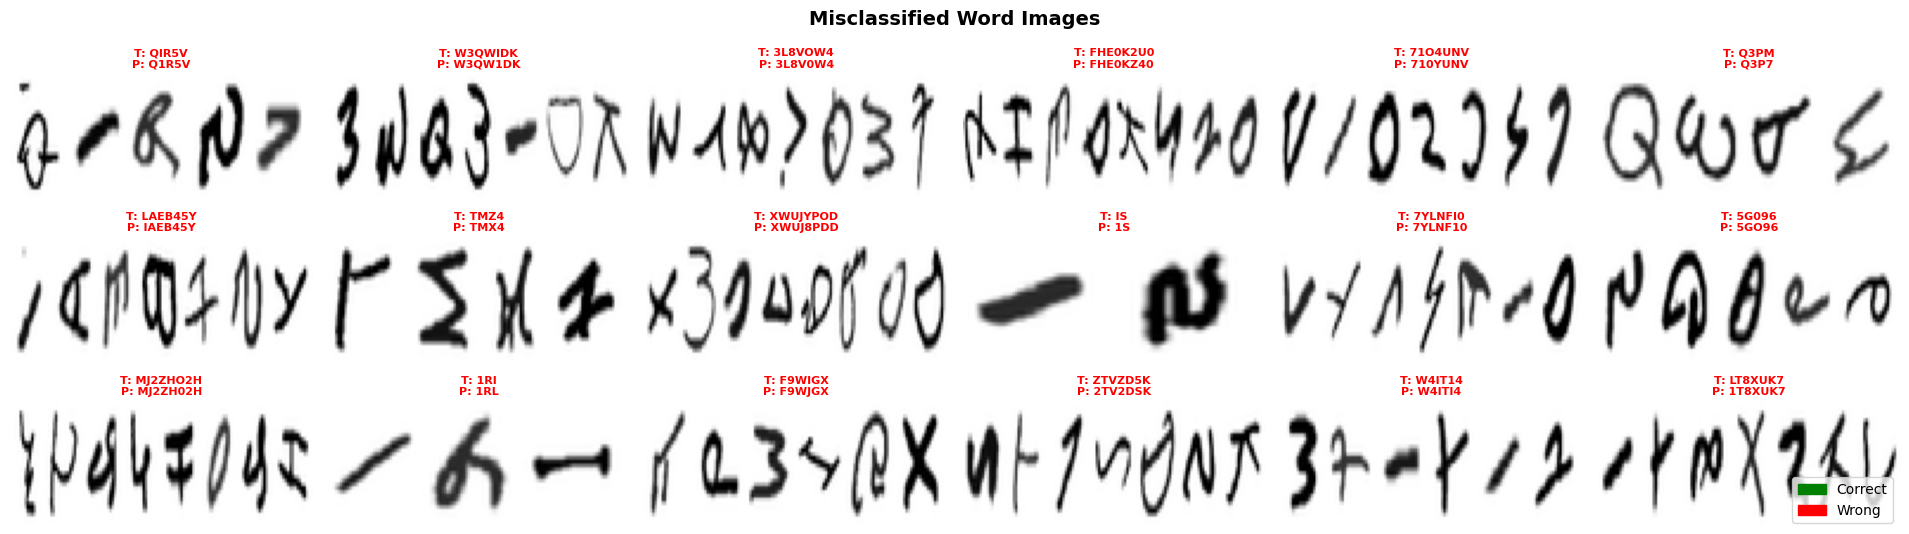

In [ ]:
def plot_predictions_grid(X_imgs, true_strs, pred_strs, n=24, title='CRNN Predictions'):
    n    = min(n, len(X_imgs))
    cols = 6
    rows = max(1, (n + cols - 1) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 1.8))
    axes = np.array(axes).flatten()

    for i in range(n):
        ax    = axes[i]
        match = true_strs[i] == pred_strs[i]
        color = 'green' if match else 'red'
        ax.imshow(X_imgs[i, :, :, 0], cmap='gray_r', aspect='auto')
        ax.set_title(
            f'T: {true_strs[i]}\nP: {pred_strs[i]}',
            fontsize=8, color=color, fontweight='bold'
        )
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)
        ax.axis('off')

    for i in range(n, len(axes)):
        axes[i].axis('off')

    green_p = mpatches.Patch(color='green', label='Correct')
    red_p   = mpatches.Patch(color='red',   label='Wrong')
    plt.legend(handles=[green_p, red_p], loc='lower right',
               bbox_to_anchor=(1, -0.05), fontsize=10)
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_predictions_grid(
    X_test, y_test_strs, y_pred_strs, n=24,
    title='CRNN Test Predictions (T=True, P=Predicted)'
)

# Separate: correct only
correct_idx = [i for i, (t, p) in enumerate(zip(y_test_strs, y_pred_strs)) if t == p]
wrong_idx   = [i for i, (t, p) in enumerate(zip(y_test_strs, y_pred_strs)) if t != p]

print(f'Correct predictions: {len(correct_idx)}')
print(f'Wrong   predictions: {len(wrong_idx)}')

if wrong_idx:
    plot_predictions_grid(
        X_test[wrong_idx[:18]],
        [y_test_strs[i] for i in wrong_idx[:18]],
        [y_pred_strs[i] for i in wrong_idx[:18]],
        n=18,
        title='Misclassified Word Images'
    )

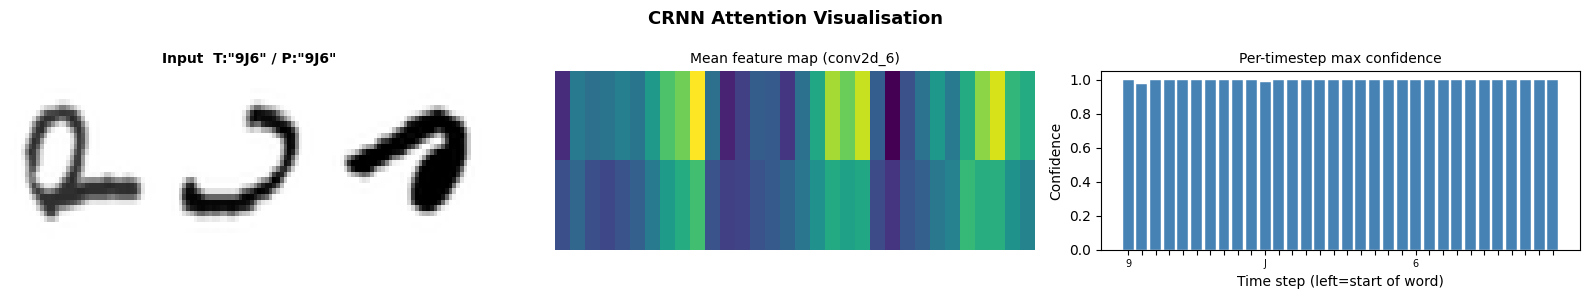

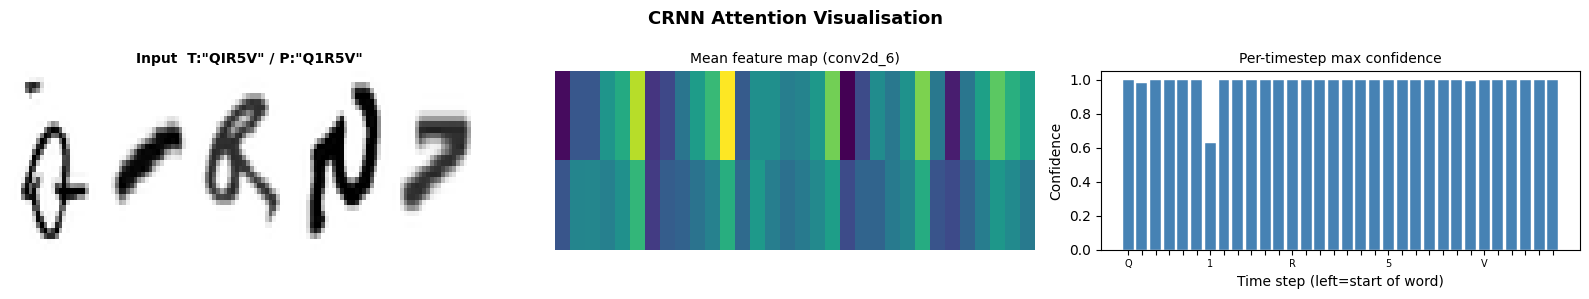

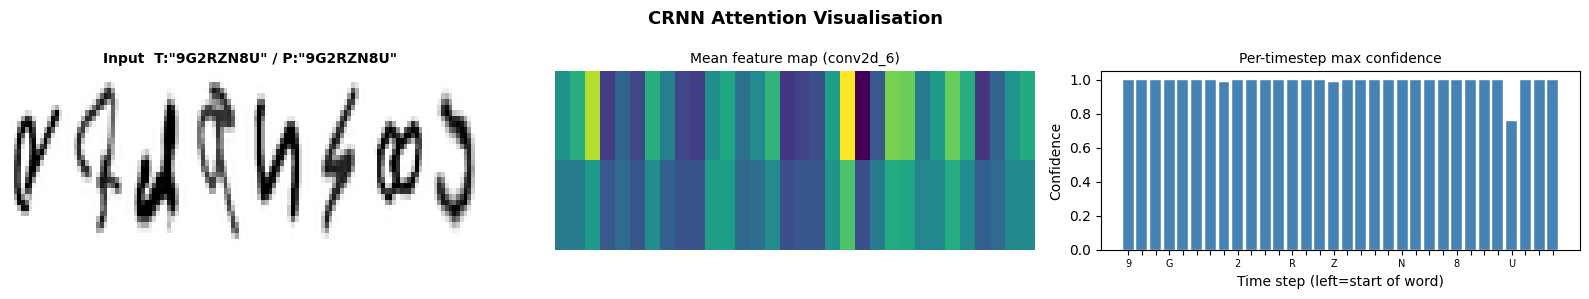

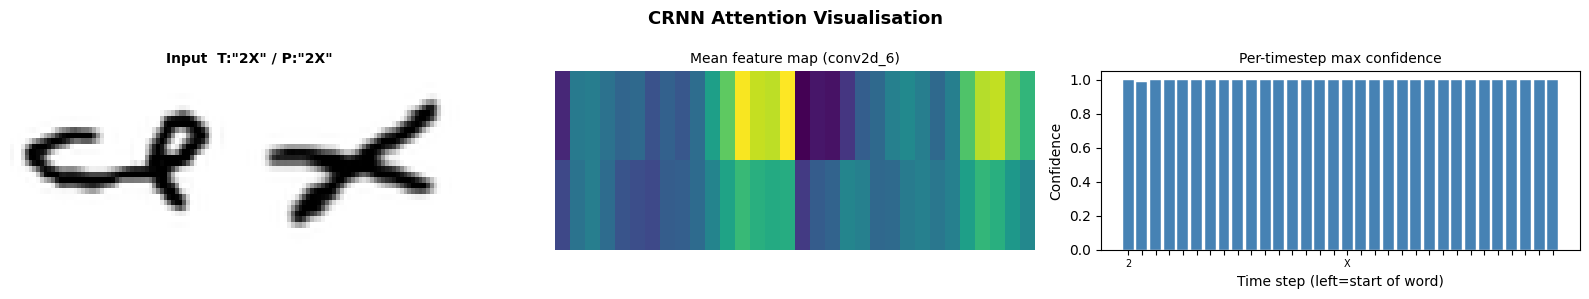

In [ ]:
def visualize_attention(crnn, image, true_label, pred_label, layer_name=None):
    """
    Show the first CNN feature maps and the per-timestep argmax predictions
    to give an intuition of where the model is 'reading'.
    """
    if layer_name is None:
        # Pick the last conv layer
        for lyr in reversed(crnn.layers):
            if 'conv2d' in lyr.name:
                layer_name = lyr.name
                break

    # Feature map at chosen layer
    feat_model = models.Model(
        inputs  = crnn.input,
        outputs = crnn.get_layer(layer_name).output
    )
    feat_maps = feat_model.predict(image[np.newaxis, ...], verbose=0)[0]
    mean_map  = np.mean(feat_maps, axis=-1)   # (H, W)

    # Per-timestep prediction
    preds      = crnn.predict(image[np.newaxis, ...], verbose=0)[0]  # (T, C)
    ts_chars   = [idx2char.get(np.argmax(p), '') for p in preds]

    fig, axes = plt.subplots(1, 3, figsize=(16, 3))

    axes[0].imshow(image[:, :, 0], cmap='gray_r', aspect='auto')
    axes[0].set_title(f'Input  T:"{true_label}" / P:"{pred_label}"',
                      fontsize=10, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(mean_map, cmap='viridis', aspect='auto')
    axes[1].set_title(f'Mean feature map ({layer_name})', fontsize=10)
    axes[1].axis('off')

    axes[2].bar(range(len(ts_chars)), [np.max(p) for p in preds],
                color='steelblue', edgecolor='white', linewidth=0.3)
    axes[2].set_xticks(range(len(ts_chars)))
    axes[2].set_xticklabels(ts_chars, fontsize=7)
    axes[2].set_title('Per-timestep max confidence', fontsize=10)
    axes[2].set_xlabel('Time step (left=start of word)')
    axes[2].set_ylabel('Confidence')
    axes[2].set_ylim([0, 1.05])

    plt.suptitle('CRNN Attention Visualisation', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Pick a few examples
for pick in range(4):
    visualize_attention(
        crnn_model,
        X_test[pick],
        y_test_strs[pick],
        y_pred_strs[pick]
    )

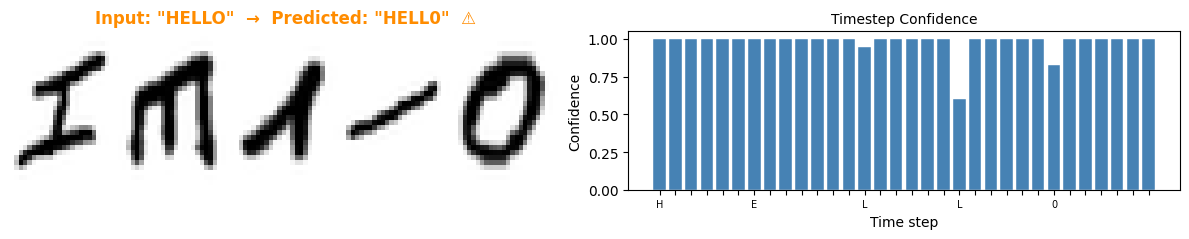

  "HELLO" → "HELL0"


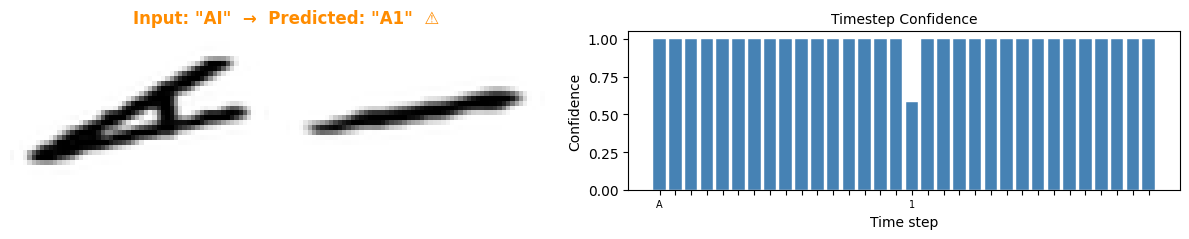

  "AI" → "A1"


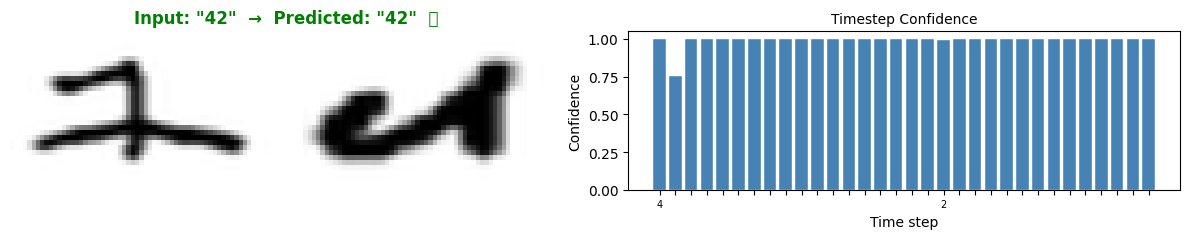

  "42" → "42"


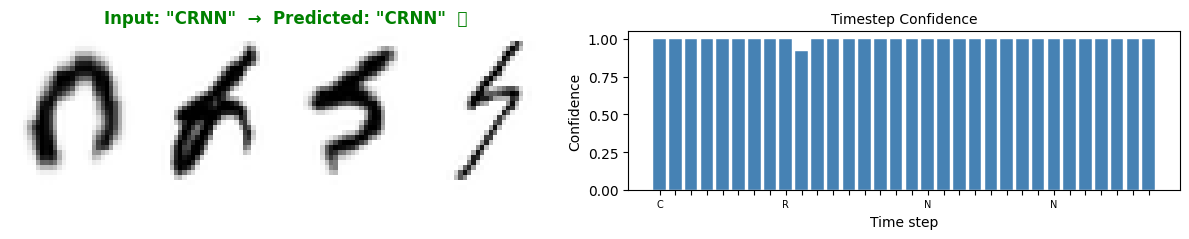

  "CRNN" → "CRNN"


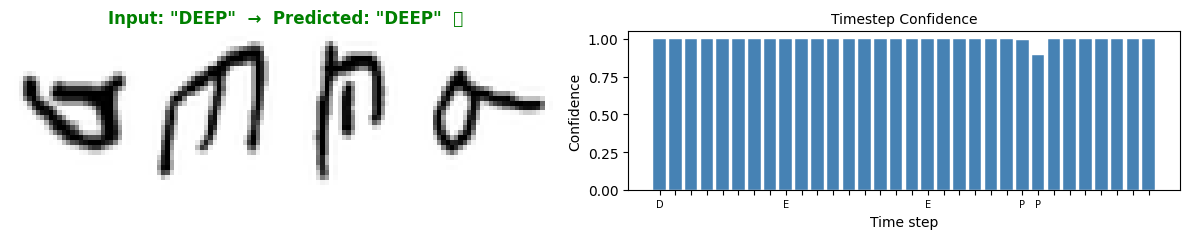

  "DEEP" → "DEEP"


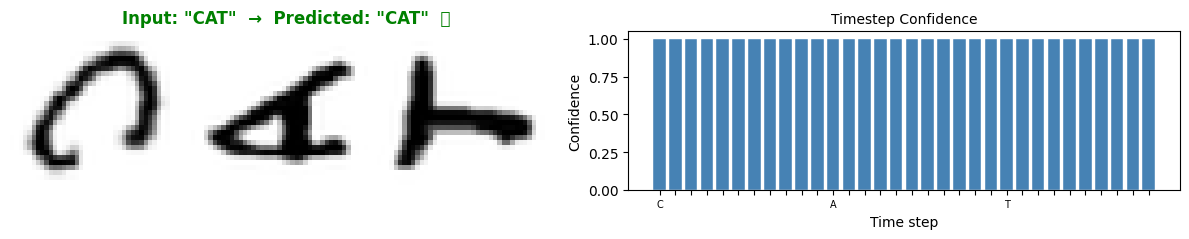

  "CAT" → "CAT"


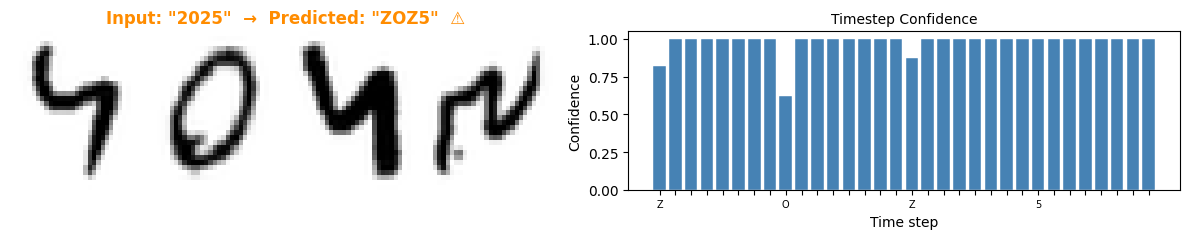

  "2025" → "ZOZ5"


In [ ]:
def predict_text(text_str, crnn, char_bank, idx2char,
                 img_h=IMG_H, img_w=IMG_W):
    """
    Build a synthetic image for text_str, run CRNN, and visualise.
    text_str: use only characters in 0-9, A-Z.
    """
    text_str = text_str.upper()   # normalise to uppercase
    img = make_word_image(text_str, char_bank, img_h=img_h,
                          img_w=img_w, augment=False)
    img_input = img[np.newaxis, :, :, np.newaxis]   # (1, H, W, 1)

    pred_raw  = crnn.predict(img_input, verbose=0)
    decoded   = ctc_greedy_decode(pred_raw, idx2char)

    fig, axes = plt.subplots(1, 2, figsize=(12, 2.5))
    axes[0].imshow(img, cmap='gray_r', aspect='auto')
    match = text_str == decoded[0]
    color = 'green' if match else 'darkorange'
    axes[0].set_title(
        f'Input: "{text_str}"  →  Predicted: "{decoded[0]}"  {"✅" if match else "⚠️"}',
        fontsize=12, fontweight='bold', color=color
    )
    axes[0].axis('off')

    # Per-timestep confidence bar
    ts_conf = [np.max(p) for p in pred_raw[0]]
    ts_char = [idx2char.get(np.argmax(p), '') for p in pred_raw[0]]
    axes[1].bar(range(len(ts_conf)), ts_conf, color='steelblue',
                edgecolor='white', linewidth=0.3)
    axes[1].set_xticks(range(len(ts_char)))
    axes[1].set_xticklabels(ts_char, fontsize=7)
    axes[1].set_ylim([0, 1.05])
    axes[1].set_title('Timestep Confidence', fontsize=10)
    axes[1].set_xlabel('Time step')
    axes[1].set_ylabel('Confidence')

    plt.tight_layout()
    plt.show()
    return decoded[0]


# ── Try your own words here ───────────────────────────────────────────────────
for test_text in ['HELLO', 'AI', '42', 'CRNN', 'DEEP', 'CAT', '2025']:
    result = predict_text(test_text, crnn_model, char_bank, idx2char)
    print(f'  "{test_text}" → "{result}"')

In [ ]:
# Save only the inference CRNN (not the CTC training wrapper)
crnn_model.save('crnn_inference.keras')
print('Saved: crnn_inference.keras')

# Also save training model weights
training_model.save_weights('crnn_training_weights.weights.h5')
print('Saved: crnn_training_weights.weights.h5')

# Reload and verify
loaded_crnn = keras.models.load_model('crnn_inference.keras')
reload_pred = loaded_crnn.predict(X_test[:4], verbose=0)
reload_dec  = ctc_greedy_decode(reload_pred, idx2char)
print('\nReloaded model test:')
for t, p in zip(y_test_strs[:4], reload_dec):
    print(f'  true={t:10s}  pred={p}')

Saved: crnn_inference.keras
Saved: crnn_training_weights.weights.h5

Reloaded model test:
  true=9J6         pred=9J6
  true=QIR5V       pred=Q1R5V
  true=9G2RZN8U    pred=9G2RZN8U
  true=2X          pred=2X


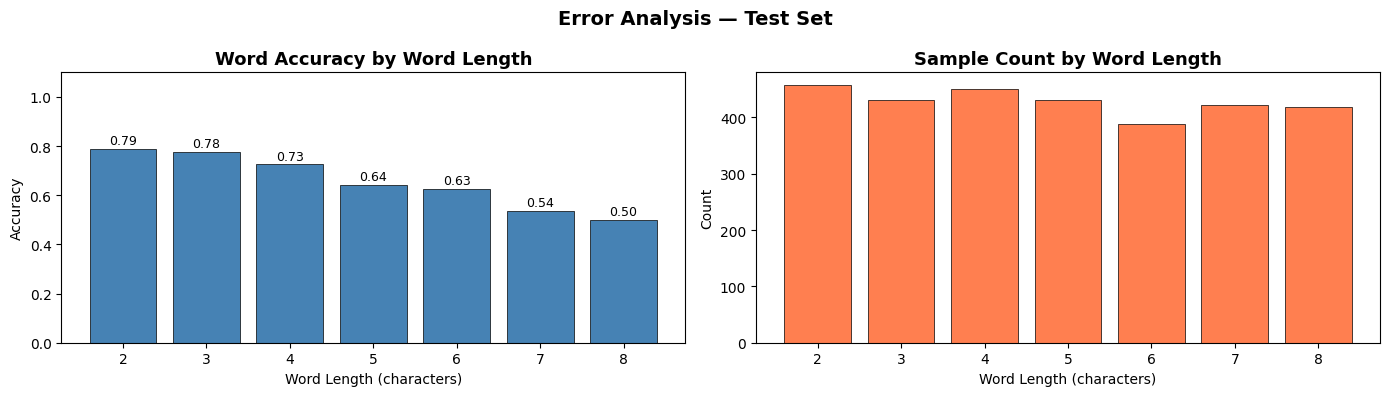

Saved: crnn_error_analysis.png


In [ ]:
# Length-wise accuracy
from collections import defaultdict

len_stats = defaultdict(lambda: {'total': 0, 'correct': 0})
for t, p in zip(y_test_strs, y_pred_strs):
    l = len(t)
    len_stats[l]['total']   += 1
    len_stats[l]['correct'] += (t == p)

lengths = sorted(len_stats.keys())
accs    = [len_stats[l]['correct'] / len_stats[l]['total'] for l in lengths]
totals  = [len_stats[l]['total'] for l in lengths]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(lengths, accs, color='steelblue', edgecolor='black', linewidth=0.5)
axes[0].set_title('Word Accuracy by Word Length', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Length (characters)')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1.1])
axes[0].set_xticks(lengths)
for x, a in zip(lengths, accs):
    axes[0].text(x, a + 0.02, f'{a:.2f}', ha='center', fontsize=9)

axes[1].bar(lengths, totals, color='coral', edgecolor='black', linewidth=0.5)
axes[1].set_title('Sample Count by Word Length', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Length (characters)')
axes[1].set_ylabel('Count')
axes[1].set_xticks(lengths)

plt.suptitle('Error Analysis — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('crnn_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: crnn_error_analysis.png')